In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False
# ---------------------- 1. 直接读取你的因子表 ----------------------
file_path = r"..\数据\DSP因子总表.csv"
df = pd.read_csv(file_path)


# 处理日期格式
df['trade_date'] = pd.to_datetime(df['trade_date'])
df = df.sort_values(['code', 'trade_date']).reset_index(drop=True)

# 查看一下字段名（确保和你的表一致）
print("因子表字段：", df.columns.tolist())
print("\n前5行数据：")
print(df.head())


因子表字段： ['trade_date', 'code', 'close_price', 'filtered_price', 'dsp_factor', 'filtered_momentum', 'original_momentum', 'noise_intensity']

前5行数据：
  trade_date       code  close_price  filtered_price  dsp_factor  \
0 2023-03-01  000333.SZ        54.62       48.632940         NaN   
1 2023-03-02  000333.SZ        54.85       48.180563         NaN   
2 2023-03-03  000333.SZ        55.20       47.732936         NaN   
3 2023-03-06  000333.SZ        53.83       47.296993         NaN   
4 2023-03-07  000333.SZ        52.86       46.879957         NaN   

   filtered_momentum  original_momentum  noise_intensity  
0                NaN                NaN              NaN  
1                NaN                NaN              NaN  
2                NaN                NaN              NaN  
3                NaN                NaN              NaN  
4                NaN                NaN              NaN  


In [2]:

# ---------------------- 2. 计算未来收益（用于因子评估） ----------------------
forward_period = 5  # 未来5日收益
df['forward_return'] = df.groupby('code')['close_price'].apply(
    lambda x: x.pct_change(forward_period).shift(-forward_period)
).reset_index(level=0, drop=True)#计算未来五天的收益率波动

# ---------------------- 3. 定义因子评估函数 ----------------------
def evaluate_single_factor(df_stock, factor_col, forward_ret_col='forward_return', quantiles=5):
    temp = df_stock[[factor_col, forward_ret_col]].copy()#保留因子值和未来收益两列
    temp = temp.dropna()
    
    if len(temp) < quantiles + 1:
        return None#数据过少不评估

    ic = temp[factor_col].corr(temp[forward_ret_col])#计算IC值
    temp['group'] = pd.qcut(temp[factor_col].rank(pct=True), quantiles, labels=False)#将因子值从低到高分成5组
    group_ret = temp.groupby('group')[forward_ret_col].mean()#计算每组未来收益的平均值
    top_ret = group_ret.iloc[-1]#因子值最大的一组
    bottom_ret = group_ret.iloc[0]#最小的一组
    long_short = top_ret - bottom_ret#做多最好组 + 做空最差组的收益
    win_rate = (temp[temp['group'] == quantiles-1][forward_ret_col] > 0).mean()#买入 Top 组后，赚钱的概率

    # ===================== 换手率计算=====================
    top_group = temp[temp['group'] == quantiles - 1].copy()
    
    # 个股自身换手率：连续两期是否在Top组
    top_group['in_top'] = 1
    top_group['prev_in_top'] = top_group['in_top'].shift(1)#上一期是否在top 里面
    top_group['turnover'] = (top_group['prev_in_top'] != 1).astype(float)
    #昨天不在top里，今天在，则为1
    avg_turnover = top_group['turnover'].mean()

    return {
        'IC': ic,
        'top_group_return': top_ret,
        'long_short_return': long_short,
        'win_rate': win_rate,
        'turnover': avg_turnover
    }


In [3]:

# ---------------------- 4. 批量评估：DSP因子 vs 传统动量 --------------------
results = []
for code, group in df.groupby('code'):
    res_dsp = evaluate_single_factor(group, 'dsp_factor')
    res_trad = evaluate_single_factor(group, 'original_momentum')
    
    if res_dsp is None or res_trad is None:
        continue
    
    results.append({
        'code': code,
        'IC_DSP': res_dsp['IC'],
        'IC_Traditional': res_trad['IC'],
        'long_short_DSP': res_dsp['long_short_return'],
        'long_short_Traditional': res_trad['long_short_return'],
        'win_rate_DSP': res_dsp['win_rate'],
        'win_rate_Traditional': res_trad['win_rate'],
        'turnover_DSP': res_dsp['turnover'],
        'turnover_Traditional': res_trad['turnover'],
    })

df_results = pd.DataFrame(results)


In [4]:

# ---------------------- 5. 输出对比结果 ----------------------
print("\n" + "="*60)
print("DSP因子 vs 传统动量因子 整体对比结果")
print("="*60)
print(f"平均IC（传统动量）: {df_results['IC_Traditional'].mean():.4f}")
print(f"平均IC（DSP因子）: {df_results['IC_DSP'].mean():.4f}")
print(f"IC提升: {(df_results['IC_DSP'].mean() - df_results['IC_Traditional'].mean()):.4f}")

print(f"\n平均多空收益（传统动量）: {df_results['long_short_Traditional'].mean():.4f}")
print(f"平均多空收益（DSP因子）: {df_results['long_short_DSP'].mean():.4f}")

print(f"\n平均多头胜率（传统动量）: {df_results['win_rate_Traditional'].mean()*100:.2f}%")
print(f"平均多头胜率（DSP因子）: {df_results['win_rate_DSP'].mean()*100:.2f}%")

print(f"\n===== 换手率对比（越低越好）=====")
print(f"平均换手率（传统动量）: {df_results['turnover_Traditional'].mean()*100:.2f}%")
print(f"平均换手率（DSP因子）: {df_results['turnover_DSP'].mean()*100:.2f}%")
print(f"换手率降低: {(df_results['turnover_Traditional'].mean() - df_results['turnover_DSP'].mean())*100:.2f} 百分点")

# 保存对比结果
df_results.to_csv(r"..\数据\因子对比结果.csv", index=False, encoding='utf-8-sig')
print("\n对比结果已保存：..\\数据\\因子对比结果.csv")



DSP因子 vs 传统动量因子 整体对比结果
平均IC（传统动量）: -0.0353
平均IC（DSP因子）: 0.0818
IC提升: 0.1171

平均多空收益（传统动量）: 0.0006
平均多空收益（DSP因子）: 0.0166

平均多头胜率（传统动量）: 47.70%
平均多头胜率（DSP因子）: 53.93%

===== 换手率对比（越低越好）=====
平均换手率（传统动量）: 0.76%
平均换手率（DSP因子）: 0.76%
换手率降低: 0.00 百分点

对比结果已保存：..\数据\因子对比结果.csv


C:\Users\wangwei\AppData\Local\Temp\ipykernel_11612\3634031029.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot([df_results['win_rate_Traditional'], df_results['win_rate_DSP']],
C:\Users\wangwei\AppData\Local\Temp\ipykernel_11612\3634031029.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2,0].boxplot([df_results['turnover_Traditional'].dropna(), df_results['turnover_DSP'].dropna()],


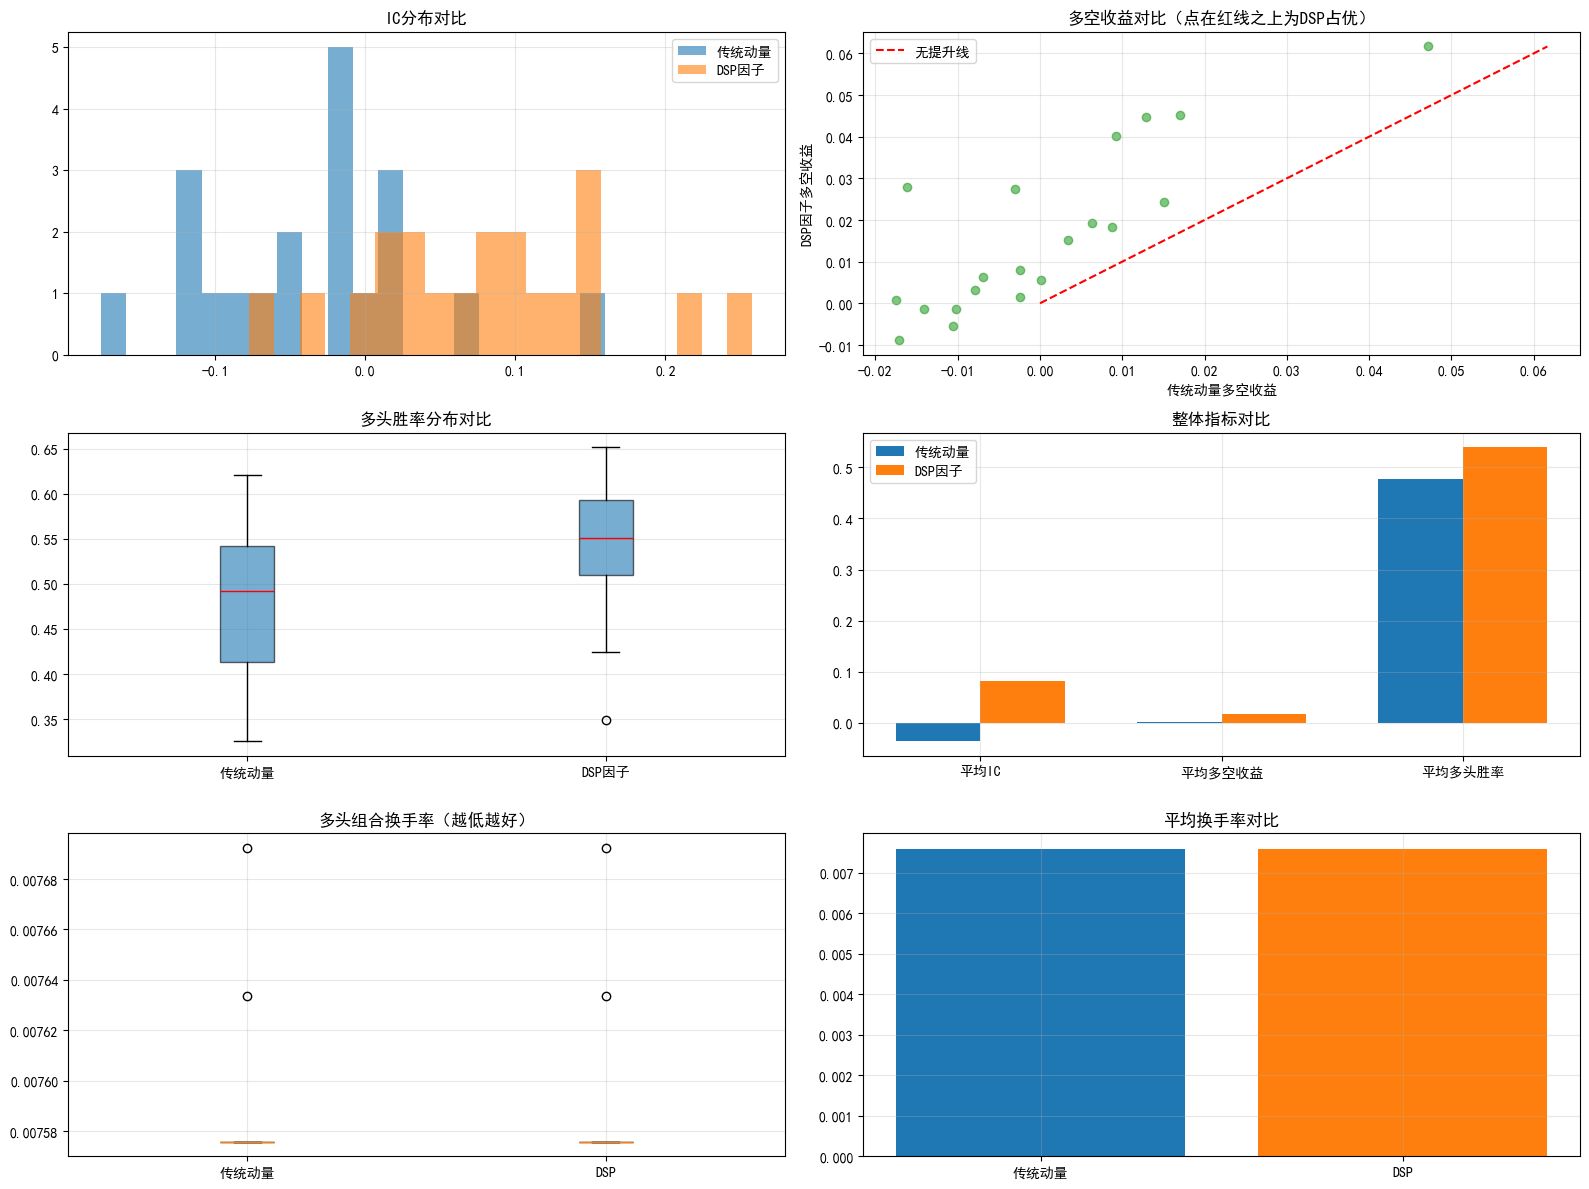

In [5]:

# ---------------------- 6. 可视化对比图 ----------------------
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# 1. IC分布对比
axes[0,0].hist(df_results['IC_Traditional'], bins=20, alpha=0.6, label='传统动量', color='#1f77b4')
axes[0,0].hist(df_results['IC_DSP'], bins=20, alpha=0.6, label='DSP因子', color='#ff7f0e')
axes[0,0].set_title('IC分布对比')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# 2. 多空收益散点图
axes[0,1].scatter(df_results['long_short_Traditional'], df_results['long_short_DSP'], alpha=0.6, color='#2ca02c')
max_val = max(df_results['long_short_Traditional'].max(), df_results['long_short_DSP'].max())
axes[0,1].plot([0, max_val], [0, max_val], 'r--', label='无提升线')
axes[0,1].set_xlabel('传统动量多空收益')
axes[0,1].set_ylabel('DSP因子多空收益')
axes[0,1].set_title('多空收益对比（点在红线之上为DSP占优）')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# 3. 多头胜率箱线图
axes[1,0].boxplot([df_results['win_rate_Traditional'], df_results['win_rate_DSP']],
                  labels=['传统动量', 'DSP因子'], patch_artist=True,
                  boxprops=dict(facecolor='#1f77b4', alpha=0.6),
                  medianprops=dict(color='red'))
axes[1,0].set_title('多头胜率分布对比')
axes[1,0].grid(alpha=0.3)

# 4. 整体指标柱状图对比
metrics = ['平均IC', '平均多空收益', '平均多头胜率']
traditional_vals = [
    df_results['IC_Traditional'].mean(),
    df_results['long_short_Traditional'].mean(),
    df_results['win_rate_Traditional'].mean()
]
dsp_vals = [
    df_results['IC_DSP'].mean(),
    df_results['long_short_DSP'].mean(),
    df_results['win_rate_DSP'].mean()
]

x = np.arange(len(metrics))
width = 0.35
axes[1,1].bar(x - width/2, traditional_vals, width, label='传统动量', color='#1f77b4')
axes[1,1].bar(x + width/2, dsp_vals, width, label='DSP因子', color='#ff7f0e')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(metrics)
axes[1,1].set_title('整体指标对比')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

# 5. 换手率箱线图
axes[2,0].boxplot([df_results['turnover_Traditional'].dropna(), df_results['turnover_DSP'].dropna()],
                  labels=['传统动量','DSP'], patch_artist=True)
axes[2,0].set_title('多头组合换手率（越低越好）')
axes[2,0].grid(alpha=0.3)

# 6. 换手率柱状图
axes[2,1].bar(['传统动量','DSP'], 
       [df_results['turnover_Traditional'].mean(), df_results['turnover_DSP'].mean()], 
       color=['#1f77b4','#ff7f0e'])
axes[2,1].set_title('平均换手率对比')
axes[2,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(r"..\数据\因子对比可视化.png", dpi=200, bbox_inches='tight')
plt.show()